# Module 11 Lab: Real-Time Object Tracking and Zone-Based Analytics

Welcome to an advanced topic in computer vision! In this lab, you will learn how to not just detect objects, but **track** them across video frames. You will also learn how to perform **zone-based analytics**, which involves analyzing object behavior within a specific region of the video.

**What you'll learn:**
- The difference between object detection and object tracking.
- How to use a pre-trained model to track objects in a video.
- How to define a 'zone' and count objects that enter it.

## Learning Objectives

By the end of this lab, you will be able to:

- **Differentiate** between object detection and object tracking.
- **Implement** an object tracking pipeline using the YOLO model.
- **Design** and implement a zone for analytics.
- **Analyze** the behavior of objects within a defined zone.

## 1. Setup and Installation

We will continue to use the `ultralytics` and `opencv-python` libraries.


In [1]:
%pip install ultralytics opencv-python requests

Now, let's import the necessary components.

In [2]:
from ultralytics import YOLO
import cv2
import requests
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

## 2. Understanding Object Tracking

### Object Detection vs. Object Tracking

- **Object Detection** is the process of identifying and locating objects in a single image or frame. It answers the question, 'What objects are in this frame and where are they?'
- **Object Tracking** is the process of identifying an object and following it across multiple frames. It answers the question, 'Where is this specific object going?' Tracking assigns a unique ID to each detected object, allowing it to be followed over time.

### Why is Tracking Useful?

Tracking is essential for many real-world applications, such as:
- **Retail Analytics:** Counting how many people enter a store and where they go.
- **Traffic Management:** Monitoring the flow of cars on a highway.
- **Security:** Following a person of interest through a building.

## Part 1: Coded Demonstration

In this part, we will track cars in a video and count how many of them enter a specific zone.

In [21]:
# 1. Load the YOLO model
model = YOLO('yolov8n.pt')

In [22]:
# 2. Download a video to analyze
import requests
video_url = 'https://storage.googleapis.com/gtv-videos-bucket/sample/SubaruOutbackOnStreetAndDirt.mp4'
r = requests.get(video_url)
with open('highway.mp4', 'wb') as f:
    f.write(r.content)
print("Download finished. Check your sidebar for highway.mp4")

Download finished. Check your sidebar for highway.mp4


In [26]:
# Delete the broken file
!rm -rf highway.mp4

# Download a reliable traffic video from GitHub
!wget -O highway.mp4 https://github.com/intel-iot-devkit/sample-videos/raw/master/car-detection.mp4

# Verify the file size (should be more than 0)
import os
if os.path.exists('highway.mp4'):
    print(f"File downloaded! Size: {os.path.getsize('highway.mp4')} bytes")

--2026-04-29 15:35:11--  https://github.com/intel-iot-devkit/sample-videos/raw/master/car-detection.mp4
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/intel-iot-devkit/sample-videos/master/car-detection.mp4 [following]
--2026-04-29 15:35:12--  https://raw.githubusercontent.com/intel-iot-devkit/sample-videos/master/car-detection.mp4
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2811553 (2.7M) [application/octet-stream]
Saving to: ‘highway.mp4’

highway.mp4         100%[===================>]   2.68M  --.-KB/s    in 0.03s   

2026-04-29 15:35:12 (83.5 MB/s) - ‘highway.mp4’ saved [2811553/2811553

Success! Starting tracking...
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 300ms
Prepared 1 package in 50ms
Installed 1 package in 4ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 1.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



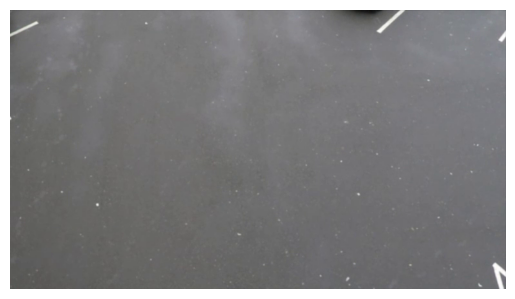

Object ID 2 crossed!


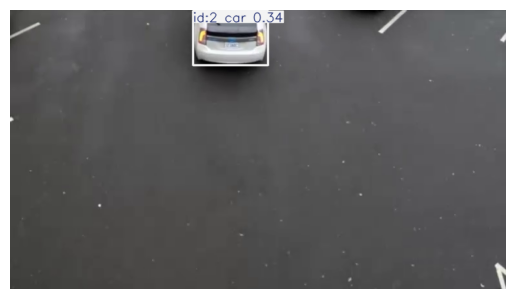

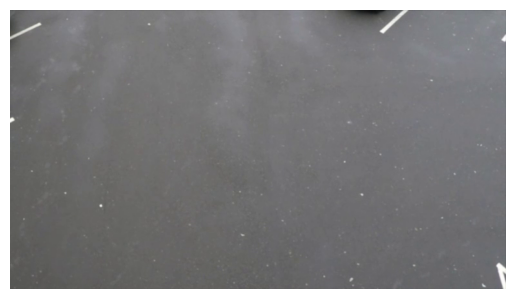

Object ID 18 crossed!


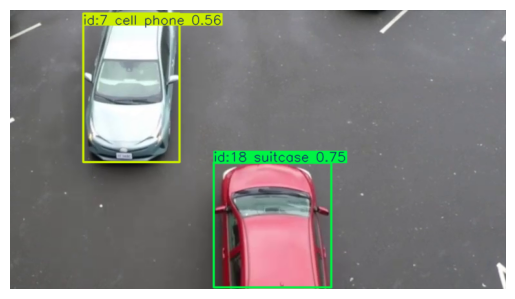

Finished! Total counted: 2


In [27]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture('highway.mp4')

if not cap.isOpened():
    print("Error: Video still won't open. Try clicking the Refresh icon in the folder sidebar.")
else:
    print("Success! Starting tracking...")
    zone_y = 300
    crossed_objects = set()

    # Process 200 frames
    for _ in range(200):
        ret, frame = cap.read()
        if not ret: break

        results = model.track(frame, persist=True, verbose=False)

        if results[0].boxes.id is not None:
            boxes = results[0].boxes.xyxy.cpu()
            track_ids = results[0].boxes.id.int().cpu().tolist()
            for box, track_id in zip(boxes, track_ids):
                if box[3] > zone_y and track_id not in crossed_objects:
                    crossed_objects.add(track_id)
                    print(f'Object ID {track_id} crossed!')

        if cap.get(cv2.CAP_PROP_POS_FRAMES) % 50 == 0:
            plt.imshow(cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.show()

    cap.release()
    print(f"Finished! Total counted: {len(crossed_objects)}")

## Part 2: Student Challenge

Your challenge is to modify the agent to count objects in a different zone. Instead of a horizontal line, you will define a **rectangular zone** and count how many objects are **inside** it in each frame.

**Your Task:**
1.  Define a rectangular zone (e.g., `zone = [x1, y1, x2, y2]`).
2.  Modify the agent to count how many objects are inside the zone in each frame.
3.  Display the count on the frame.

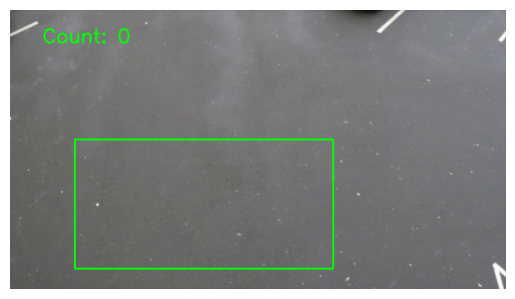

Object 21 entered the zone!


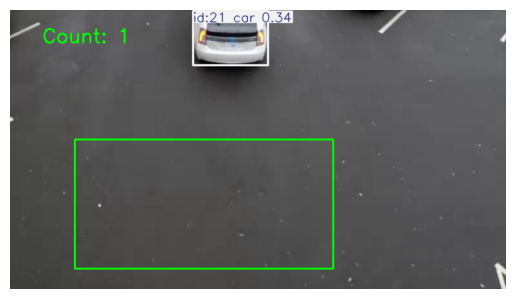

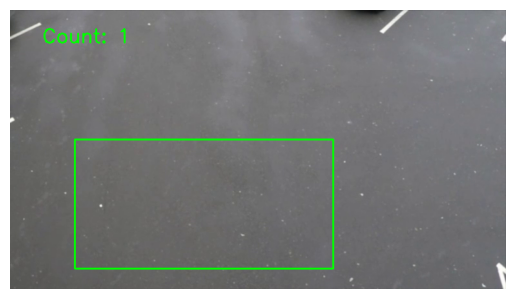

Object 26 entered the zone!


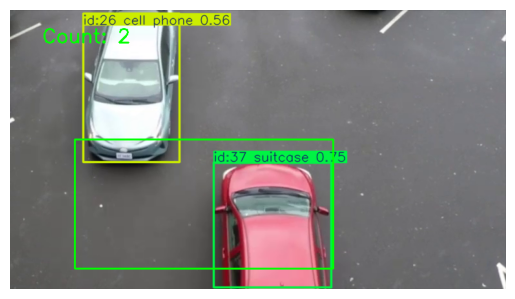

Object 37 entered the zone!


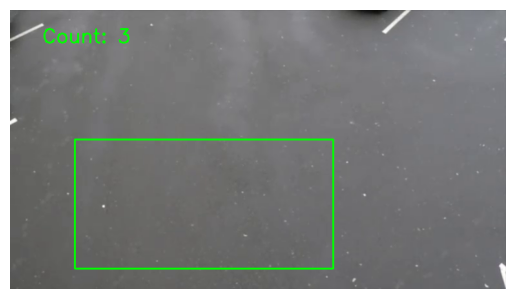

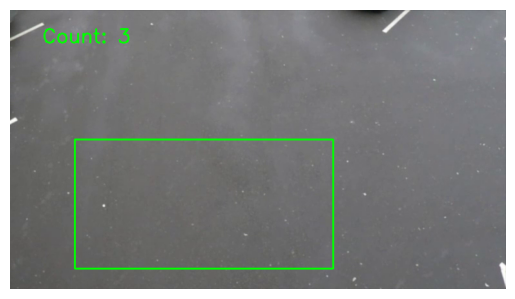

Object 51 entered the zone!


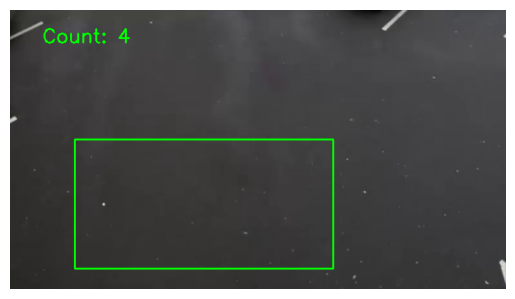

Finished! Total counted: 4


In [29]:
import cv2
import matplotlib.pyplot as plt

# --- ENTER YOUR CODE HERE ---

# 1. Define your rectangular zone
# zone = [x1, y1, x2, y2]
my_zone = [100, 200, 500, 400]

# 2. Create your new agent function
def zone_counting_agent(video_path):
    cap = cv2.VideoCapture(video_path)

    # Store IDs of objects currently in the zone
    objects_in_zone = set()

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Run the tracking model
        results = model.track(frame, persist=True, verbose=False)
        annotated_frame = results[0].plot()

        # 2. Draw the rectangle (using the zone coordinates defined above)
        cv2.rectangle(annotated_frame, (my_zone[0], my_zone[1]), (my_zone[2], my_zone[3]), (0, 255, 0), 2)

        if results[0].boxes.id is not None:
            boxes = results[0].boxes.xyxy.cpu()
            track_ids = results[0].boxes.id.int().cpu().tolist()

            for box, track_id in zip(boxes, track_ids):
                # Using simple X and Y coordinates from the box (intro style)
                x_coord = box[0]
                y_coord = box[3]

                # 3. Check if the object is inside the box boundaries
                if x_coord > my_zone[0] and x_coord < my_zone[2]:
                    if y_coord > my_zone[1] and y_coord < my_zone[3]:
                        if track_id not in objects_in_zone:
                            objects_in_zone.add(track_id)
                            print(f"Object {track_id} entered the zone!")

        # 4. Display the count on the frame (Requirement #3)
        cv2.putText(annotated_frame, f"Count: {len(objects_in_zone)}", (50, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        # Show progress images
        if cap.get(cv2.CAP_PROP_POS_FRAMES) % 50 == 0:
            plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.show()

    cap.release()
    print(f"Finished! Total counted: {len(objects_in_zone)}")

# 3. Run your new agent
zone_counting_agent('highway.mp4')

## Reflective Questions

Please answer the following questions in a new Markdown cell below.

1.What is the key difference between `model.predict()` and `model.track()` in the YOLO library?

For modelpredict() the model is simply bounding items it dectects in the image and giving it a ID number, whereas with model.track() the model is following and image in multiple frame and place bounding boxes around that item in each frame.

2.In our coded demonstration, we only counted an object once when it crossed the line. How did we achieve this? Why is it important?

We achieved this by using object_in_zone, which allows and ID to be assigned to an object so that is not counted more than once. It is important because we wound not want multiple results of th same car because it is just stationary, we want the cars to be tracked.

3.Describe a real-world application for zone-based analytics. What kind of zone would you define, and what would you measure?

A real-world application for zone-based analtics I would use would be if I was a owner of a fast food restaurant. I would use it to define a zone at the drive-thru window to get a true understanding of traffic and wait times based on times of the day, so that I could evaluate busy times to make sure I'm staffed correctly.

4.What are some of the challenges in object tracking? (e.g., what happens if an object is hidden for a few frames?)

A challenge in object tracking is when the object goes behind another object. For example with this lab if the car we are tracking goes behind a truck. When this occurs the model may get confused and assign the ID of the car it was tracking to the truck, and give the car a new ID when it reappears from behind the truck which will mess up the count.

## Submission Instructions

1.  Complete the **Student Challenge** section with your modified agent.
2.  Answer the **Reflective Questions** in a new Markdown cell.
3.  Save your completed notebook (`.ipynb` file) and submit it.